---
title: "Exploratory Data Analysis"
format:
    html: 
        code-fold: false
        embed-resources: true

---


{{< include overview.qmd >}} 

{{< include method.qmd >}} 

Below, we will explain how we performed EDA for the following datasets: 


If you need a refresher on the data sources, visit the link below:

**[Visit Data Source Information Here](../data-collection/overview.qmd)**

# Code

## EDA: Ride Accuracy Binary dataset

In [1]:
#import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
#load ride accuracy csv file dataset for eda
ride_accuracy = pd.read_csv("../../data/processed-data/Clean_Ride_Accuracy_Binary.csv")

#convert csv file into a dataframe
ride_accuracy_df = pd.DataFrame(ride_accuracy)

print(ride_accuracy_df.head())

#drop unneeded columns
ride_accuracy_drop_df = ride_accuracy_df.drop(["Unnamed: 0"],axis=1)

   Unnamed: 0      weekly    mode route_id        bin arrival_departure  \
0         780  2020-08-03  subway     Blue    0-3 min           blended   
1         781  2020-08-03  subway     Blue    3-6 min           blended   
2         782  2020-08-03  subway     Blue   6-12 min           blended   
3         783  2020-08-03  subway     Blue  12-30 min           blended   
4         784  2020-08-03  subway  Green-B    0-3 min           blended   

   num_predictions  num_accurate_predictions  Low Range Bin Time (min)  \
0            63612                     58116                         0   
1            65346                     58809                         3   
2           124158                    112668                         6   
3           350575                    314248                        12   
4           144067                    117550                         0   

   High Range Bin Time (min)  Pre and Post 2021  Pre and Post 2021 Binary  
0                          3

### Univariate analysis: 

In [3]:
#find outliers and other statistical information using describe()
print(ride_accuracy_drop_df.describe())

       num_predictions  num_accurate_predictions  Low Range Bin Time (min)  \
count     7.184000e+03               7184.000000               7184.000000   
mean      1.900083e+05             154576.004176                  5.250000   
std       1.842277e+05             144457.231305                  4.437369   
min       0.000000e+00                  0.000000                  0.000000   
25%       7.617800e+04              67576.000000                  2.250000   
50%       1.199255e+05             101258.000000                  4.500000   
75%       2.237600e+05             187399.250000                  7.500000   
max       1.158573e+06             904424.000000                 12.000000   

       High Range Bin Time (min)  Pre and Post 2021  Pre and Post 2021 Binary  
count                7184.000000       7.184000e+03               7184.000000  
mean                   12.750000       1.662738e+09                  0.670379  
std                    10.473909       3.750476e+07      

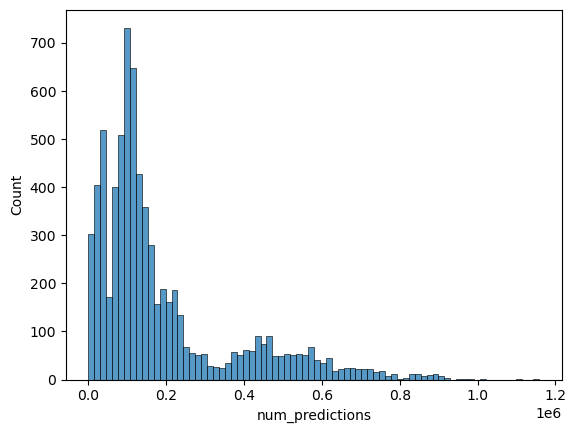

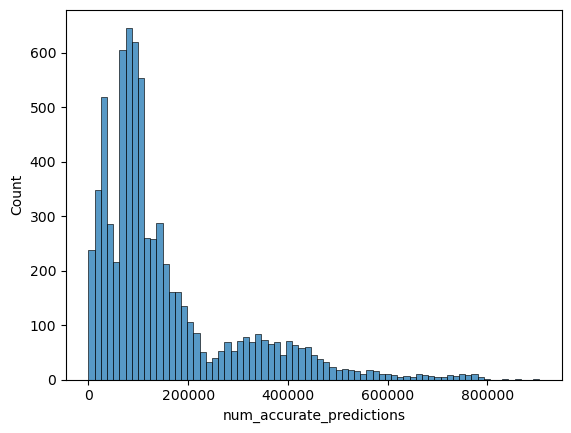

In [4]:
#create histogram plot for num_predictions column
sns.histplot(data = ride_accuracy_drop_df, x = "num_predictions")
plt.show()

#create histogram plot for num_accurate_predictions column
sns.histplot(data = ride_accuracy_drop_df, x = "num_accurate_predictions")
plt.show()

*HISTOGRAM ANALYSIS*

* Above show the distribution of the "num_predictions" and "num_accurate predictions". Both histograms have a right skew meaning there were fewer number of predictions and accurate preditictions of subway rides. Not too many outliers.

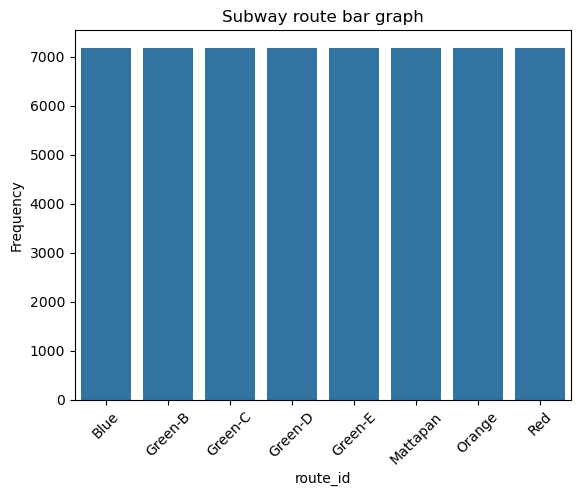

In [5]:
#bar charts to observe categorical variables: different subway routes
route_count = ride_accuracy_drop_df["route_id"].count()

sns.barplot(data = ride_accuracy_drop_df, x = "route_id", y = route_count)
plt.title("Subway route bar graph")
plt.xticks(rotation=45)
plt.ylabel("Frequency")
plt.show()

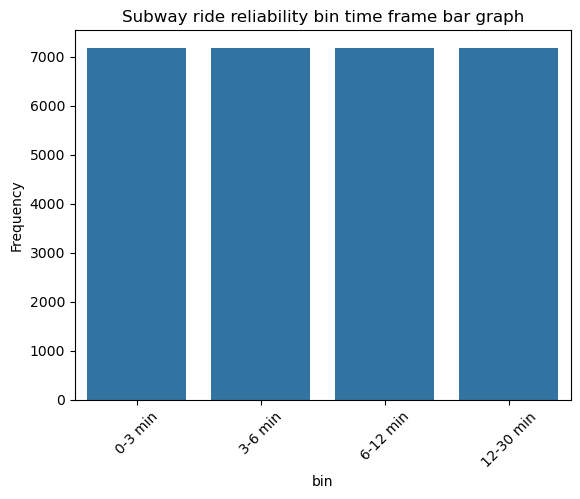

In [6]:
#bar charts to observe categorical variables: bin column
bin_count = ride_accuracy_drop_df["bin"].count()

sns.barplot(data = ride_accuracy_drop_df, x = "bin", y = bin_count)
plt.title("Subway ride reliability bin time frame bar graph")
plt.xticks(rotation=45)
plt.ylabel("Frequency")
plt.show()

*BAR PLOT ANALYSIS*

* Bar plots above shows the frequency of the categorical variables: route_id and bin. Bar plots show that the number of observations are uniform for all the unique categorical features.

### Bivariate and Multivariate Analysis:

                           num_predictions  num_accurate_predictions  \
num_predictions                   1.000000                  0.982956   
num_accurate_predictions          0.982956                  1.000000   
Low Range Bin Time (min)          0.701063                  0.678770   
High Range Bin Time (min)         0.734128                  0.707786   
Pre and Post 2021 Binary         -0.051032                 -0.067263   

                           Low Range Bin Time (min)  \
num_predictions                        7.010633e-01   
num_accurate_predictions               6.787704e-01   
Low Range Bin Time (min)               1.000000e+00   
High Range Bin Time (min)              9.804686e-01   
Pre and Post 2021 Binary               1.068438e-15   

                           High Range Bin Time (min)  Pre and Post 2021 Binary  
num_predictions                         7.341277e-01             -5.103219e-02  
num_accurate_predictions                7.077863e-01             -6.726284

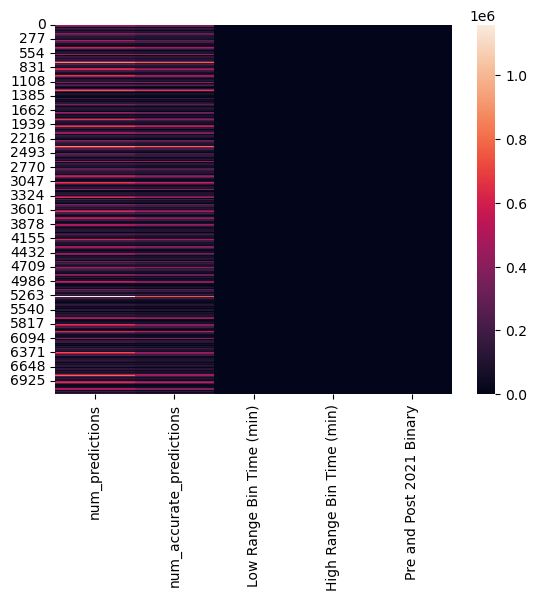

In [7]:
#create correlation matrix of the ride reliability dataframe
#first subset dataframe to only include numerical columns
rel_subset = ride_accuracy_drop_df[["num_predictions",  "num_accurate_predictions", "Low Range Bin Time (min)", "High Range Bin Time (min)", "Pre and Post 2021 Binary"]]
#create correlation matrix
rel_corr_matrix = rel_subset.corr()
print(rel_corr_matrix)


#create heatmap of dataframe subset
sns.heatmap(rel_subset)
plt.show() #show heatmap

*CORRELATION MATRIX* 

* The correlation matrix show majority of features in the ride accuracy dataset have high correlation. But majority of those correalations are due to multicollinearity. The heatmap helps to visualize the relations shown in the correlation matrix. The heatmap shows that "num_prediction" and "num_accurate_predictions" features have higher correlation values, and the rest of the features "Low Range Bin Time (min)" and "High Range Bin Time (min)" and "Pre and Post 2021 Binary" have lower correlation values. Thus, it would be best to fit either "num_prediction" or "num_accurate_predictions" in a model to avoid multicollinearity.

In [8]:
#create crosstab of categorical variables
#crosstab variables mode of transportation and the subway route id
pd.crosstab(ride_accuracy_drop_df["mode"], ride_accuracy_drop_df["route_id"])

route_id,Blue,Green-B,Green-C,Green-D,Green-E,Mattapan,Orange,Red
mode,,,,,,,,
subway,900,900,900,900,900,900,884,900


In [9]:
#create crosstab of data between before and after 2022-01-01 and the subway route ids
pd.crosstab(ride_accuracy_drop_df["Pre and Post 2021 Binary"], ride_accuracy_drop_df["route_id"])

route_id,Blue,Green-B,Green-C,Green-D,Green-E,Mattapan,Orange,Red
Pre and Post 2021 Binary,,,,,,,,
0,296,296,296,296,296,296,296,296
1,604,604,604,604,604,604,588,604


In [10]:
#create crosstab of data between before and after 2022-01-01 and the bin of ride arrival time frame
pd.crosstab(ride_accuracy_drop_df["Pre and Post 2021 Binary"], ride_accuracy_drop_df["bin"])

bin,0-3 min,12-30 min,3-6 min,6-12 min
Pre and Post 2021 Binary,,,,
0,592,592,592,592
1,1204,1204,1204,1204


In [11]:
#create crosstab of data between before and after 2022-01-01 and the type of trips made
pd.crosstab(ride_accuracy_drop_df["Pre and Post 2021 Binary"], ride_accuracy_drop_df["arrival_departure"])

arrival_departure,blended
Pre and Post 2021 Binary,
0,2368
1,4816


*CROSSTAB ANALYSIS* 

* The crosstabs above shows the relationship of the categorical variables in the ride accuracy dataset. The first crosstab shows the data only includes data on the subway mode of transportation and includes the subway route ids.
The second crosstab shows there were more observations of the subway route-ids post-2021.
The third crosstab shows there were more observations of ride accuracy predictions made post 2021.
The fourth crosstab shows there were more blended trips (round-trips: both departure and arrival) made post 2021.

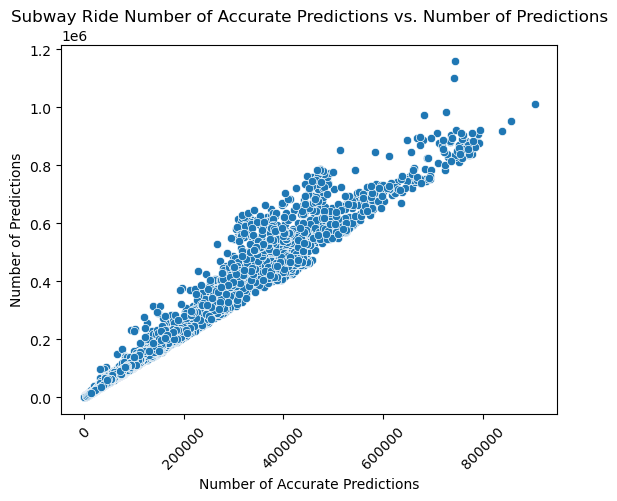

In [12]:
#Feature pairings
#create scatter plots between num_accurate_predictions and num_predictions
sns.scatterplot(data = ride_accuracy_drop_df, x= "num_accurate_predictions", y = "num_predictions")
plt.title("Subway Ride Number of Accurate Predictions vs. Number of Predictions")
plt.xticks(rotation=45)
plt.xlabel("Number of Accurate Predictions")
plt.ylabel("Number of Predictions")
plt.show()

*SCATTERPLOT ANALYSIS*
* The scatter plot shows the relationship between the number of accurate predictions on subway trips made on time and the number of predictions made of subway trips. Plot shows strong positive correlation between the two features, which may also be due to multicollinearity. More ride predictions implies more of the predictions are accurate.

### Data Distribution and Normalization: 

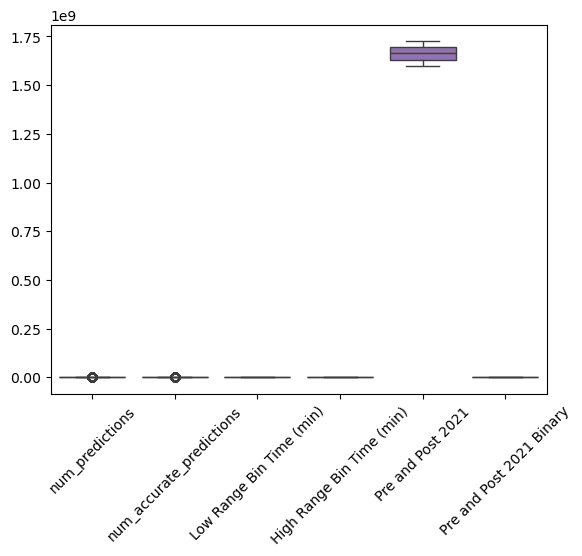

In [13]:
#create boxplot of dataframe to visualize dataset distribution
sns.boxplot(data=ride_accuracy_drop_df)
plt.xticks(rotation=45)
plt.show()

*BOXPLOT ANALYSIS* 

Boxplot shows distribution of the numerical features of the ride accuracy dataset. Boxplot shows there are no significant outliers in the dataset. The pre and post 2021 feature appears to have the most range.

In [14]:
#apply z-score normalization on subset of dataframe that only includes numerical values
#convert subset dataframe into an array
#Only select num_predictions and num_accurate_predictions
accuracy_subset = ride_accuracy_drop_df[["num_predictions", "num_accurate_predictions"]]
ride_accuracy_array = np.array(accuracy_subset)

#compute z-score normalization transformation on array of dataframe subset (x-mean)/standard deviation
normalized_ride_accuracy = (ride_accuracy_array - np.mean(ride_accuracy_array) / np.std(ride_accuracy_array))
print(normalized_ride_accuracy)

[[ 63610.96505666  58114.96505666]
 [ 65344.96505666  58807.96505666]
 [124156.96505666 112666.96505666]
 ...
 [103571.96505666  82494.96505666]
 [203963.96505666 163503.96505666]
 [582949.96505666 397087.96505666]]


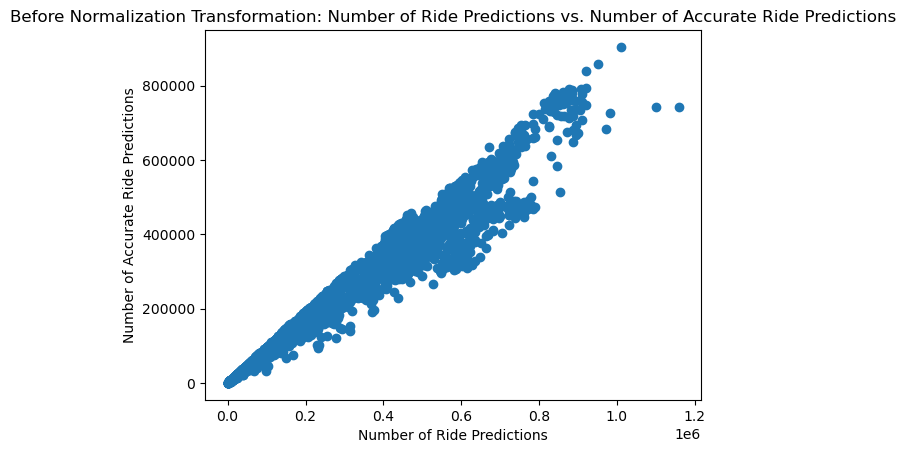

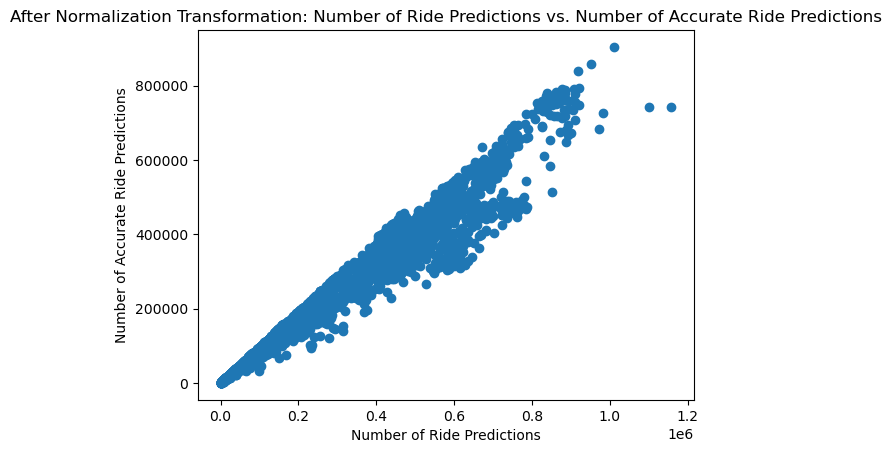

In [15]:
#scatter plot of original data of the "num_predictions" and "num_accurate_predictions" columns before normalization transformation
plt.scatter(ride_accuracy_drop_df["num_predictions"], ride_accuracy_drop_df["num_accurate_predictions"])
plt.title("Before Normalization Transformation: Number of Ride Predictions vs. Number of Accurate Ride Predictions")
plt.xlabel("Number of Ride Predictions")
plt.ylabel("Number of Accurate Ride Predictions")
plt.show()

#scatter plot of original data of the "num_predictions" and "num_accurate_predictions" columns after normalization transformation
#scatter plot shows normalization of dataset is not necessary
plt.scatter(normalized_ride_accuracy[:,0], normalized_ride_accuracy[:,1])
plt.title("After Normalization Transformation: Number of Ride Predictions vs. Number of Accurate Ride Predictions")
plt.xlabel("Number of Ride Predictions")
plt.ylabel("Number of Accurate Ride Predictions")
plt.show()

*SCATTERPLOT ANALYSIS* 

* The first scatterplot shows the relationship between the number of accurate predictions on subway trips made on time and the number of predictions made of subway trips before normalization applied. The second scatter plot shows the same two features after normalization applied. Z-score normalization was applied to the data to address any outliers. There were no signigicant difference in data point distances between the first and second scatter plot, so normalization is not needed for the data.

### Stat Insights

In [16]:
#Logistic regression model
#determine relationship between the number of predictions and accurate predictions with binary values of the dates
#import the statsmodel libary
import statsmodels.api as sm
#fit logistic regression model onto the Pre and Post 2021 Binary and num_accurate_predictions column of dataset
log_accuracy_model = sm.Logit(ride_accuracy_drop_df["Pre and Post 2021 Binary"], sm.add_constant(ride_accuracy_drop_df["num_accurate_predictions"])).fit()
#print logistic model summary
print(log_accuracy_model.summary())

Optimization terminated successfully.
         Current function value: 0.631700
         Iterations 5
                              Logit Regression Results                              
Dep. Variable:     Pre and Post 2021 Binary   No. Observations:                 7184
Model:                                Logit   Df Residuals:                     7182
Method:                                 MLE   Df Model:                            1
Date:                      Mon, 16 Dec 2024   Pseudo R-squ.:                0.003487
Time:                              16:11:13   Log-Likelihood:                -4538.1
converged:                             True   LL-Null:                       -4554.0
Covariance Type:                  nonrobust   LLR p-value:                 1.744e-08
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                        0.8

*ANALYSIS*

* Logistic regression models were created to predict whether the features can predict whether the event of the trip occurred pre or post 1/1/2021, where the predictor are the binary values of date - pre and post 2021. Looking at the logistic regression model, the features num_predictions and num_accurate_predictions are likely better predictors of the Pre and Post 2021 Binary feature because the p-values are 0.000.

In [17]:
#create a new subset of dataset, drop the Pre and Post 2021 Binary because that column will be used as the predictor to be fit in the logistic regression model
rel_subset2 = rel_subset.drop("Pre and Post 2021 Binary", axis=1)
print(rel_subset2.columns) #print columns of new subset data as checkpoint

Index(['num_predictions', 'num_accurate_predictions',
       'Low Range Bin Time (min)', 'High Range Bin Time (min)'],
      dtype='object')


In [18]:
#fit logistic regression model onto the Pre and Post 2021 Binary and num_accurate_predictions column of dataset
log_accuracy_model2 = sm.Logit(ride_accuracy_drop_df["Pre and Post 2021 Binary"], sm.add_constant(rel_subset2)).fit()
#print logistic model summary
print(log_accuracy_model2.summary())

Optimization terminated successfully.
         Current function value: 0.627313
         Iterations 5
                              Logit Regression Results                              
Dep. Variable:     Pre and Post 2021 Binary   No. Observations:                 7184
Model:                                Logit   Df Residuals:                     7179
Method:                                 MLE   Df Model:                            4
Date:                      Mon, 16 Dec 2024   Pseudo R-squ.:                 0.01041
Time:                              16:11:13   Log-Likelihood:                -4506.6
converged:                             True   LL-Null:                       -4554.0
Covariance Type:                  nonrobust   LLR p-value:                 1.261e-19
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                         

In [19]:
#two-sample t-test
#import the scipy.stats library
import scipy.stats as stats

#perform two-sample t-test on the "Pre and Post 2021 Binary" and "num_accurate_predictions" features
t_stat, p_value = stats.ttest_ind(ride_accuracy_drop_df["Pre and Post 2021 Binary"], ride_accuracy_drop_df["num_accurate_predictions"])
print("T-statistic: ", t_stat) #print t-statistic
print("p-value: ", p_value) #print p-value

#perform two-sample t-test on the "Pre and Post 2021 Binary" and "num_predictions" features
t_stat2, p_value2 = stats.ttest_ind(ride_accuracy_drop_df["Pre and Post 2021 Binary"], ride_accuracy_drop_df["num_predictions"])
print("T-statistic: ", t_stat2) #print t-statistic
print("p-value: ", p_value2) #print p-value

#perform two-sample t-test on the "Pre and Post 2021 Binary" and "Low Range Bin Time (min)" features
t_stat3, p_value3 = stats.ttest_ind(ride_accuracy_drop_df["Pre and Post 2021 Binary"], ride_accuracy_drop_df["Low Range Bin Time (min)"])
print("T-statistic: ", t_stat3) #print t-statistic
print("p-value: ", p_value3) #print p-value

#perform two-sample t-test on the "Pre and Post 2021 Binary" and "High Range Bin Time (min)" features
t_stat4, p_value4 = stats.ttest_ind(ride_accuracy_drop_df["Pre and Post 2021 Binary"], ride_accuracy_drop_df["High Range Bin Time (min)"])
print("T-statistic: ", t_stat4) #print t-statistic
print("p-value: ", p_value4) #print p-value


T-statistic:  -90.69515095798823
p-value:  0.0
T-statistic:  -87.41768526850058
p-value:  0.0
T-statistic:  -86.98884263601893
p-value:  0.0
T-statistic:  -97.6541427631758
p-value:  0.0


*T-TEST ANALYSIS* 

* The t-tests compares the means between two group features to see if there are obvious differences between the means of the feature groups compared to within its own group. The t-tests show that the comparision of the "Pre and Post 2021 Binary" feature and "num_accurate_predictions", "num_predictions", "Low Range Bin Time (min)", "High Range Bin Time (min)" have large t-values, meaning there are large differences between those two groups compared to the variation with the feature groups. The p-value shows there are significance between the two feature groups.

### Data Visualization and Storytelling:

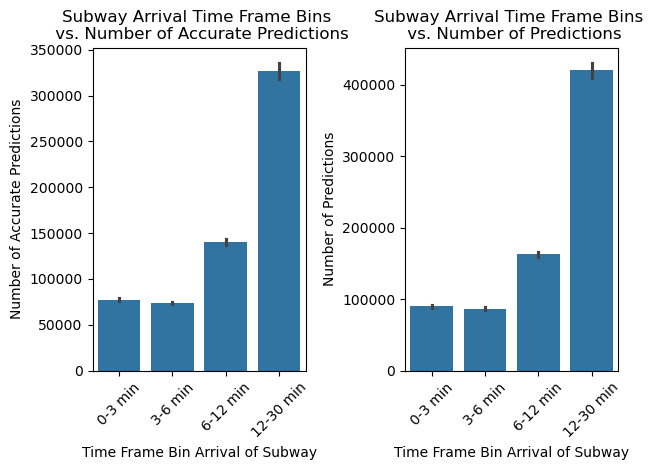

In [20]:
#create bar plot to show number of accurate prediction of subway rides and their arrival timeframe bins
plt.subplot(1,2,1) #create first plot. First row, 2 columns, 1st subplot
sns.barplot(data = ride_accuracy_drop_df, x = "bin", y = "num_accurate_predictions")
plt.title("Subway Arrival Time Frame Bins \n vs. Number of Accurate Predictions")
plt.ylabel("Number of Accurate Predictions")
plt.xlabel("Time Frame Bin Arrival of Subway")
plt.xticks(rotation=45)


#create bar plot to show number of prediction of subway rides and their arrival timeframe bins
#create second subplot
plt.subplot(1,2,2)
sns.barplot(data = ride_accuracy_drop_df, x = "bin", y = "num_predictions")
plt.title("Subway Arrival Time Frame Bins \n vs. Number of Predictions")
plt.ylabel("Number of Predictions")
plt.xlabel("Time Frame Bin Arrival of Subway")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

*BAR PLOTS ANALYSIS* 

* Bar plots above shows the time frame (bins) that subway trip arrived in vs. whether the prediction was accurate. Bar plot shows there were fewer number of accurate predictions made compared to the number of predictions. There were more subway trips arriving late in the 12-30 min bin.

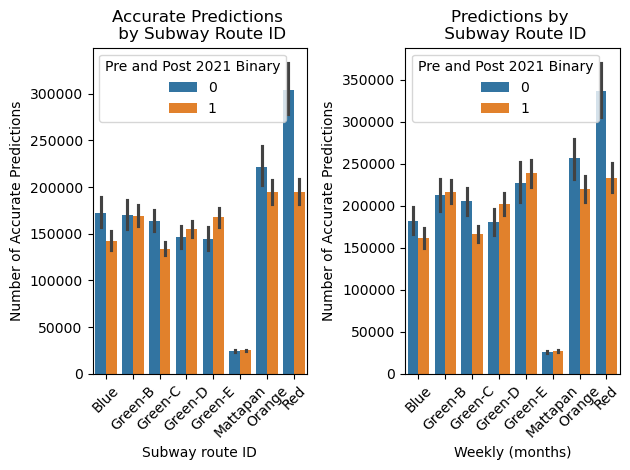

In [21]:
plt.subplot(1,2,1) #create first plot. First row, 2 columns, 1st subplot
sns.barplot(data = ride_accuracy_drop_df, hue = "Pre and Post 2021 Binary", y = "num_accurate_predictions", x = "route_id")
plt.title("Accurate Predictions \n by Subway Route ID")
plt.xlabel("Subway route ID")
plt.ylabel("Number of Accurate Predictions")
plt.xticks(rotation=45)

plt.subplot(1,2,2)
sns.barplot(data = ride_accuracy_drop_df, hue = "Pre and Post 2021 Binary", y = "num_predictions", x = "route_id")
plt.title("Predictions by \n Subway Route ID")
plt.xlabel("Weekly (months)")
plt.ylabel("Number of Accurate Predictions")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

*BAR PLOTS ANALYSIS* 

* The two bar plots show the different subway routes vs. number of accurate trip predictions post and pre 1-1-2021. Bar plots shows no significant frequency trend in number of trip predictions and accurate preditictions pre and post 2021.

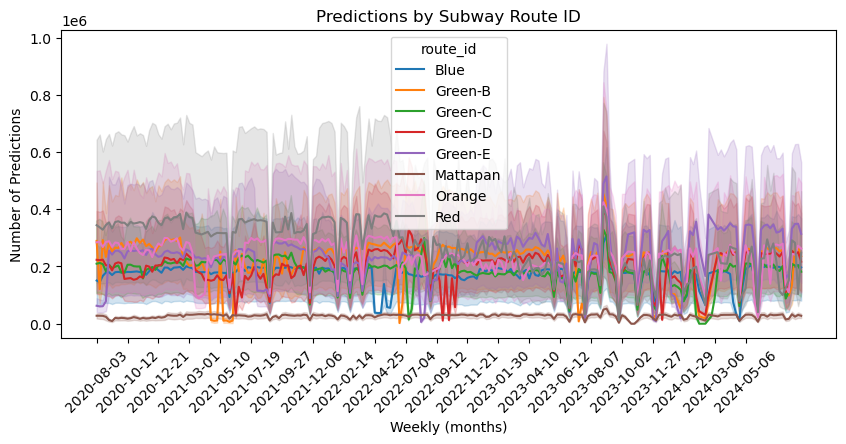

In [22]:
plt.figure(figsize=(10,4))
sns.lineplot(data = ride_accuracy_drop_df, x = "weekly", y = "num_predictions", hue = "route_id")
plt.title("Predictions by Subway Route ID")
plt.xlabel("Weekly (months)")
plt.ylabel("Number of Predictions")
plt.xticks(range(0,220,10))
plt.xticks(rotation=45)
plt.show()

*LINE GRAPH ANALYSIS* 

* Line graph shows the trend of number of predictions on subway rides made between 8/3/2020 and 5/6/2024. Plot shows steady trend in number of trip predications made throughtout the years, there appeared to be a spike in ride predictions in between 6/12/2023 and 8/7/2023.

<Figure size 1000x400 with 0 Axes>

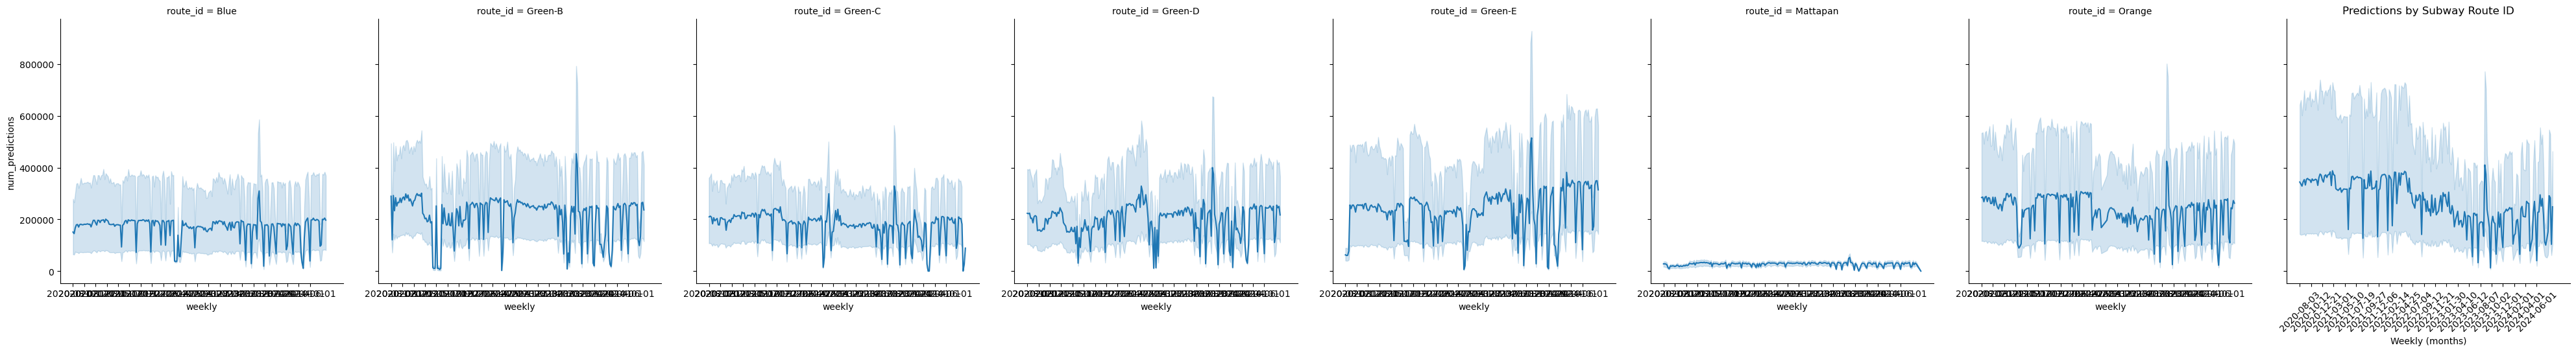

In [23]:
plt.figure(figsize=(10,4))
sns.relplot(data = ride_accuracy_drop_df, x = "weekly", y = "num_predictions", col = "route_id", kind="line")
plt.title("Predictions by Subway Route ID")
plt.xlabel("Weekly (months)")
plt.ylabel("Number of Predictions")
plt.xticks(range(0,220,10))
plt.xticks(rotation=45)
plt.show()

*MORE LINE GRAPH ANALYSIS*

* The line graph above shows the same information as the previous line graph this time broken down by the subway route ids for close inspection. There no siginificant trends in the number of predictions made throughout the years by subway route-ids.

## Ride Reliability

In [24]:
ride_rel = pd.read_csv("../../data/processed-data/Clean_Ride_Reliability.csv")

#convert csv file into a dataframe
ride_rel_df = pd.DataFrame(ride_rel)

print(ride_rel_df.head())

   Unnamed: 0               trip_date  ontime_trip_count  trip_count  \
0           0  2014/07/01 04:00:00+00               5479        5884   
1           1  2014/07/02 04:00:00+00               5297        5612   
2           2  2014/07/03 04:00:00+00               4959        5306   
3           3  2014/07/04 04:00:00+00               1530        1558   
4           4  2014/07/05 04:00:00+00               2420        2580   

   ObjectId        Date         Time  
0         1  2014-07-01  04:00:00+00  
1         2  2014-07-02  04:00:00+00  
2         3  2014-07-03  04:00:00+00  
3         4  2014-07-04  04:00:00+00  
4         5  2014-07-05  04:00:00+00  


In [25]:
data_2019_subset = ride_rel_df[ride_rel_df["Date"] > '2019-01-01']

In [26]:
max_trip = data_2019_subset.nlargest(5000, "ontime_trip_count")

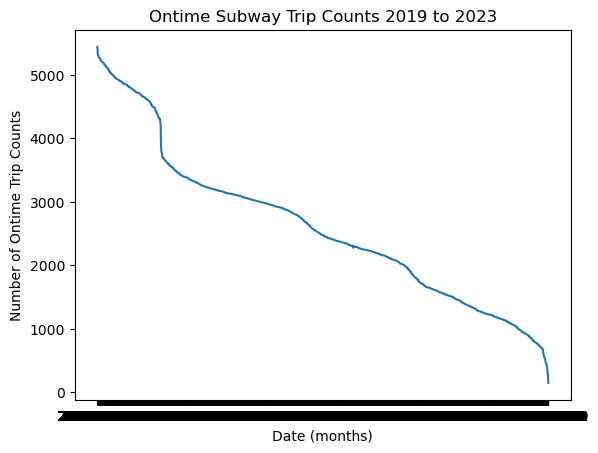

In [27]:
sns.lineplot(data = max_trip, x = "Date", y = "ontime_trip_count")
plt.title("Ontime Subway Trip Counts 2019 to 2023")
plt.xlabel("Date (months)")
plt.ylabel("Number of Ontime Trip Counts")
plt.show()

*LINE GRAPH ANALYSIS* 

* Line graph shows trend of number of subway rides that were on time from the ride reliability dataset. Plot shows there was a steady decrease in the number of on time trends as the years continued.

## Alerts EDA 

### Univariate Analysis

         cause cause_detail  effect effect_detail severity_level  severity  \
0  maintenance  maintenance  detour        detour         SEVERE         7   
1  maintenance  maintenance  detour        detour         SEVERE         7   
2  maintenance  maintenance  detour        detour         SEVERE         7   
3  maintenance  maintenance  detour        detour         SEVERE         7   
4  maintenance  maintenance  detour        detour         SEVERE         7   

  description route_id      stop_id  year affected_direction affected_stops  
0     Unknown      117  Unspecified  2024                NaN            NaN  
1     Unknown      117  Unspecified  2024                NaN            NaN  
2     Unknown      117  Unspecified  2024                NaN            NaN  
3     Unknown      117  Unspecified  2024                NaN            NaN  
4     Unknown      117  Unspecified  2024                NaN            NaN  
Most Frequent Causes of Alerts:
cause
unknown cause        1173

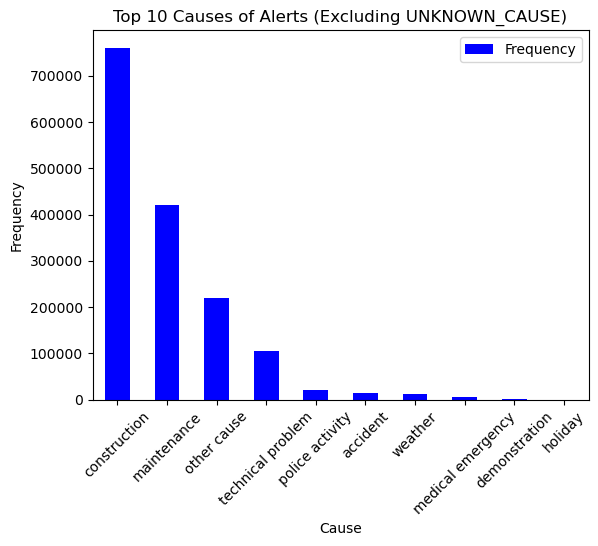

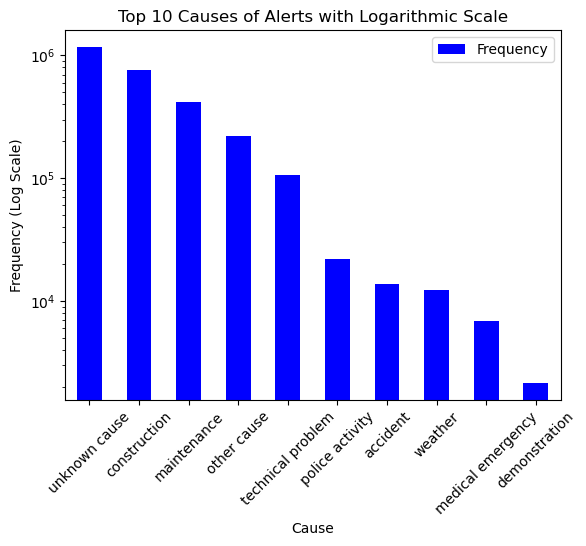

In [51]:
file_path = '../../data/processed-data/processed_alerts.csv' 

# Load the dataset
merged_alerts_cleaned = pd.read_csv(file_path)

print(merged_alerts_cleaned.head())


cause_counts = merged_alerts_cleaned['cause'].value_counts()
print("Most Frequent Causes of Alerts:")
print(cause_counts)



# Convert cause_counts to a DataFrame for easier filtering
cause_counts_df = cause_counts.reset_index()
cause_counts_df.columns = ['Cause', 'Frequency']

cause_counts_df = cause_counts_df[cause_counts_df['Frequency'] > 0]

# Filter out the dominant category (e.g., 'UNKNOWN_CAUSE') to focus on smaller causes
filtered_cause_counts_df = cause_counts_df[cause_counts_df['Cause'] != 'unknown cause']

# Bar chart for the top 10 causes excluding 'UNKNOWN_CAUSE'
filtered_cause_counts_df.head(10).set_index('Cause').plot(kind='bar', title='Top 10 Causes of Alerts (Excluding UNKNOWN_CAUSE)', color='blue')
plt.xlabel('Cause')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

# Alternatively, apply a logarithmic scale to handle wide-ranging values
cause_counts_df.head(10).set_index('Cause').plot(kind='bar', logy=True, title='Top 10 Causes of Alerts with Logarithmic Scale', color='blue')
plt.xlabel('Cause')
plt.ylabel('Frequency (Log Scale)')
plt.xticks(rotation=45)
plt.show()

*TOP CAUSES* 

- found that construction and maintenance were among the most frequent contributors. This aligns with the MBTA's ongoing renovation efforts. However, accidents and technical issues also play a significant role, adding complexity to the system's challenges.


**Cause: Accidents, Construction, and Maintenance** 

year
2020    2273
2021    2646
2022    3480
2023    2987
2024    2247
dtype: int64


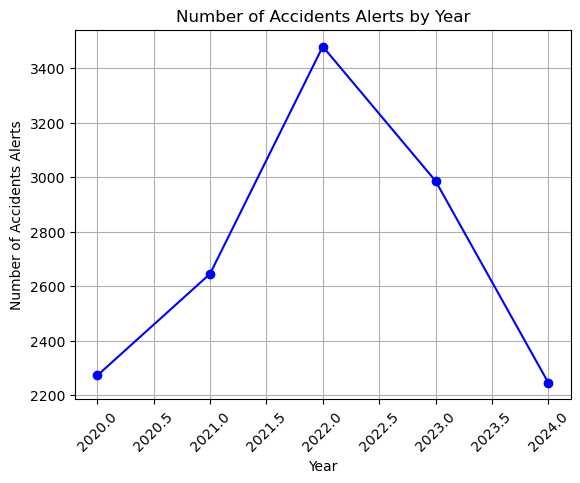

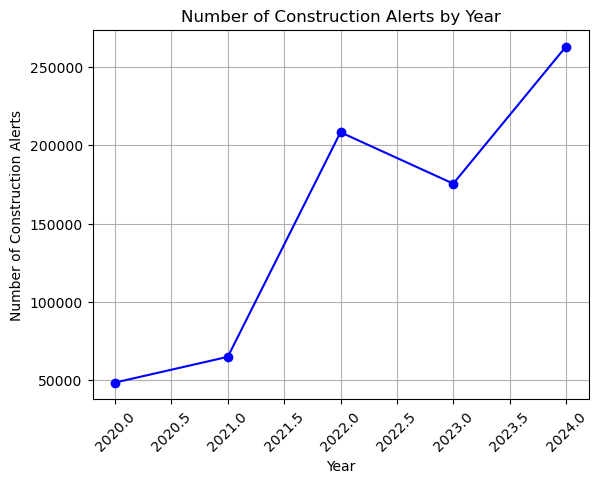

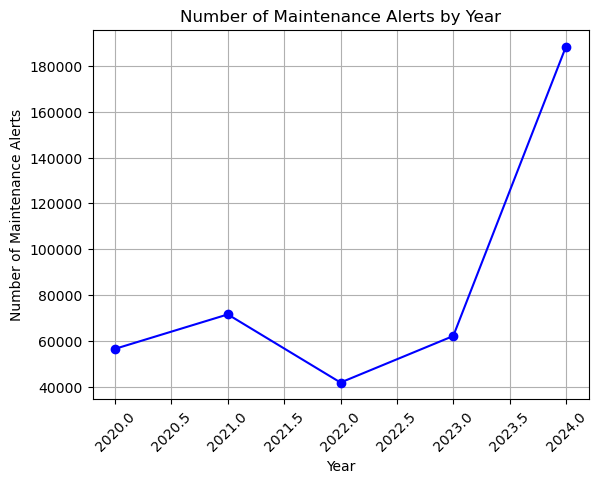

In [52]:
# Filter rows where 'cause' indicates 'accident'
accidents_data = merged_alerts_cleaned[merged_alerts_cleaned['cause'].str.contains('accident', na=False, case=False)]

# Filter rows where 'cause' indicates 'construction'
construction_data = merged_alerts_cleaned[merged_alerts_cleaned['cause'].str.contains('construction', na=False, case=False)]

# Filter rows where 'cause' indicates 'maintainance'
maintenance_data = merged_alerts_cleaned[merged_alerts_cleaned['cause'].str.contains('maintenance', na=False, case=False)]

# Count accidents by year
accidents_by_year = accidents_data.groupby('year').size()
construction_by_year = construction_data.groupby('year').size()
maintenance_by_year = maintenance_data.groupby('year').size()

# Display the counts
print(accidents_by_year)

# Line graph for accidents by year
plt.plot(accidents_by_year.index, accidents_by_year.values, marker='o', linestyle='-', color='blue')
plt.title('Number of Accidents Alerts by Year')
plt.xlabel('Year')
plt.ylabel('Number of Accidents Alerts')
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

# Line graph for construction by year
plt.plot(construction_by_year.index, construction_by_year.values, marker='o', linestyle='-', color='blue')
plt.title('Number of Construction Alerts by Year')
plt.xlabel('Year')
plt.ylabel('Number of Construction Alerts')
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

# Line graph for maintenance by year
plt.plot(maintenance_by_year.index, maintenance_by_year.values, marker='o', linestyle='-', color='blue')
plt.title('Number of Maintenance Alerts by Year')
plt.xlabel('Year')
plt.ylabel('Number of Maintenance Alerts')
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

*SUBCATEGORIES OF CAUSES EXPLORED OVER THE YEARS* 

- notable spike in accidents in 2022, which aligns with major incidents we know occurred that year. Additionally, 2024 shows the highest levels of construction and maintenance alerts, which could indicate progress in addressing infrastructure challenges. This suggests that while disruptions are increasing, they may be a sign of necessary improvements taking place

**Effect by year** 

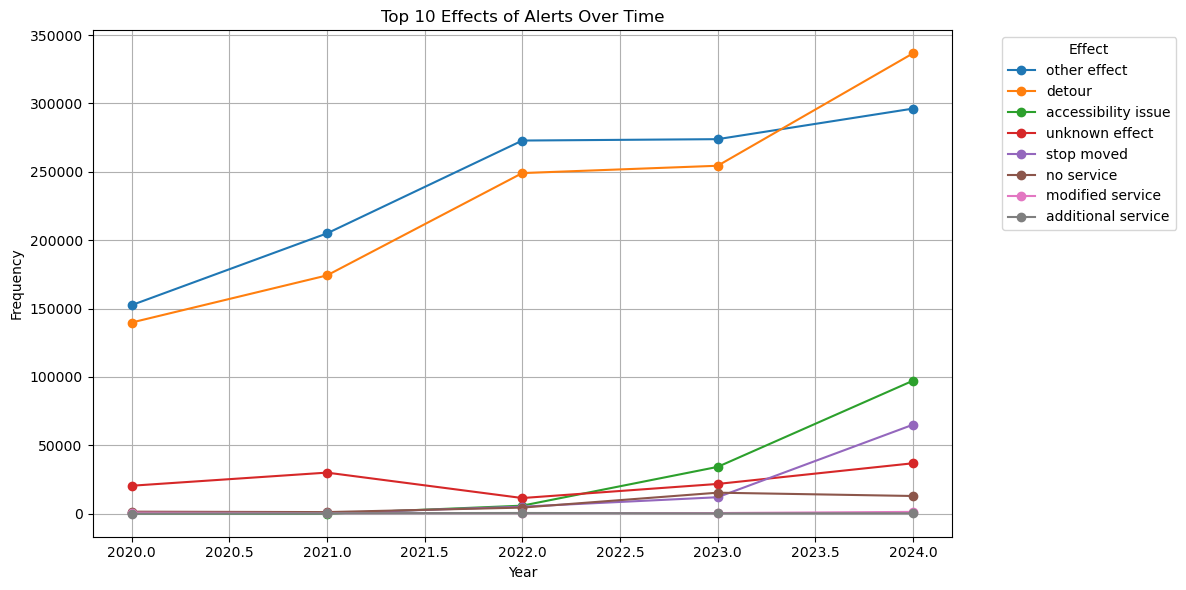

In [53]:
# Group by 'year' and 'effect' to calculate frequencies by year
effects_by_year = merged_alerts_cleaned.groupby(['year', 'effect']).size().unstack(fill_value=0)

# Get the top 10 most frequent effects from the entire dataset
top_effects = merged_alerts_cleaned['effect'].value_counts().head(10).index.tolist()

# Filter the grouped data to include only the top 10 effects
effects_by_year_top = effects_by_year[top_effects]

# Plot trends for the top 10 effects over time
effects_by_year_top.plot(kind='line', figsize=(12, 6), marker='o', title='Top 10 Effects of Alerts Over Time')
plt.xlabel('Year')
plt.ylabel('Frequency')
plt.legend(title='Effect', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()



*EFFECTS OVER TIME*

- Detours, followed by accessibility and stop movd are some of the top three common effects from alerts. 

**Severity by Year** 

Severity Level Distribution by Year:
severity_level    INFO  SEVERE  WARNING
year                                   
2020             60086  169828    85912
2021             96033  202173   113485
2022            141865  195420   212680
2023             93655  278947   239953
2024            247052  270790   328949


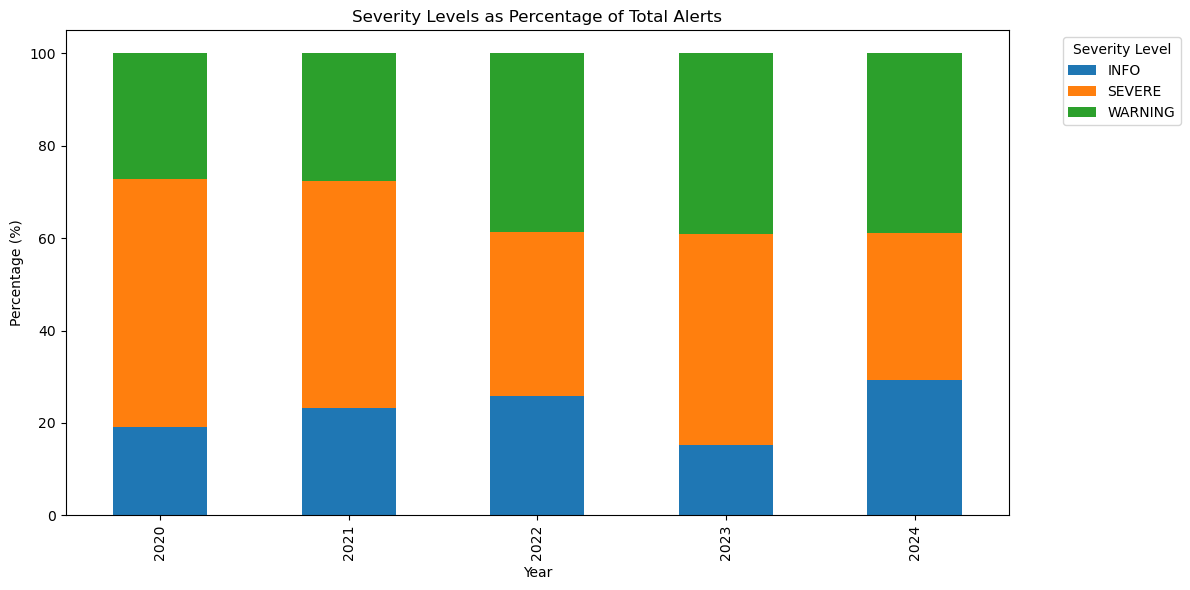

In [54]:
# Group by 'year' and 'severity_level' to calculate frequency of severity levels by year
severity_by_year = merged_alerts_cleaned.groupby(['year', 'severity_level']).size().unstack(fill_value=0)

# Print the severity distribution by year
print("Severity Level Distribution by Year:")
print(severity_by_year)

severity_by_year_percent = severity_by_year.div(severity_by_year.sum(axis=1), axis=0) * 100
severity_by_year_percent.plot(kind='bar', stacked=True, figsize=(12, 6), title='Severity Levels as Percentage of Total Alerts')
plt.xlabel('Year')
plt.ylabel('Percentage (%)')
plt.legend(title='Severity Level', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

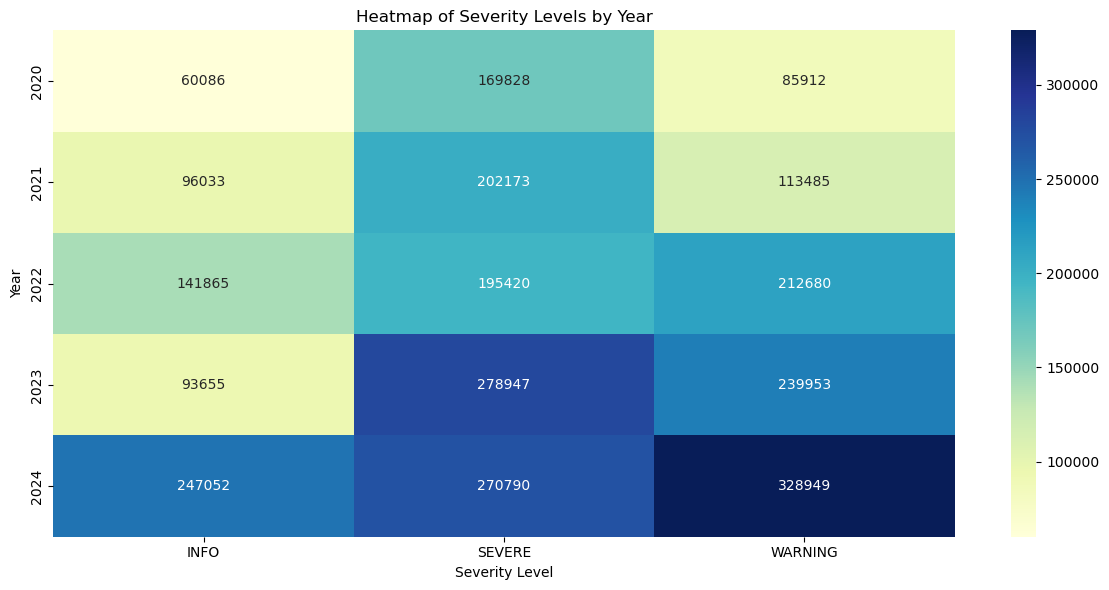

In [55]:

plt.figure(figsize=(12, 6))
sns.heatmap(severity_by_year, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Heatmap of Severity Levels by Year')
plt.xlabel('Severity Level')
plt.ylabel('Year')
plt.tight_layout()
plt.show()

*SEVERITY LEVELS BY YEARS*

- examined the severity distribution of alerts. 2020 had the highest percentage of severe incidents, likely due to operational challenges during the early pandemic. While 2022 features a lower percentage of severe alerts, the volume of incidents increased dramatically, reinforcing the need for systemic improvements. 

Most Affected Routes:
route_id
CR-Worcester      288912
451               149191
CR-Newburyport    137202
Green-B           137060
Green-D           134547
CR-Fitchburg      124749
Red               111782
Unspecified       108719
CR-Lowell          89028
120                60192
Name: count, dtype: int64
Most Affected Stops:
stop_id
Unspecified      594191
141               65187
2936              39036
1060              24367
1123              17604
WML-0442-CS       16573
2444              13482
2755              13402
West Natick       13226
Natick Center     13222
Name: count, dtype: int64
severity_level    INFO  SEVERE  WARNING
route_id                               
CR-Worcester    120835   81865    86212
451              82361   66568      262
CR-Newburyport    8817   65423    62962
Green-B          77479   35091    24490
Green-D          43099   64898    26550
CR-Fitchburg     11582   23793    89374
Red              26144   57136    28502
Unspecified       2380     157   10618

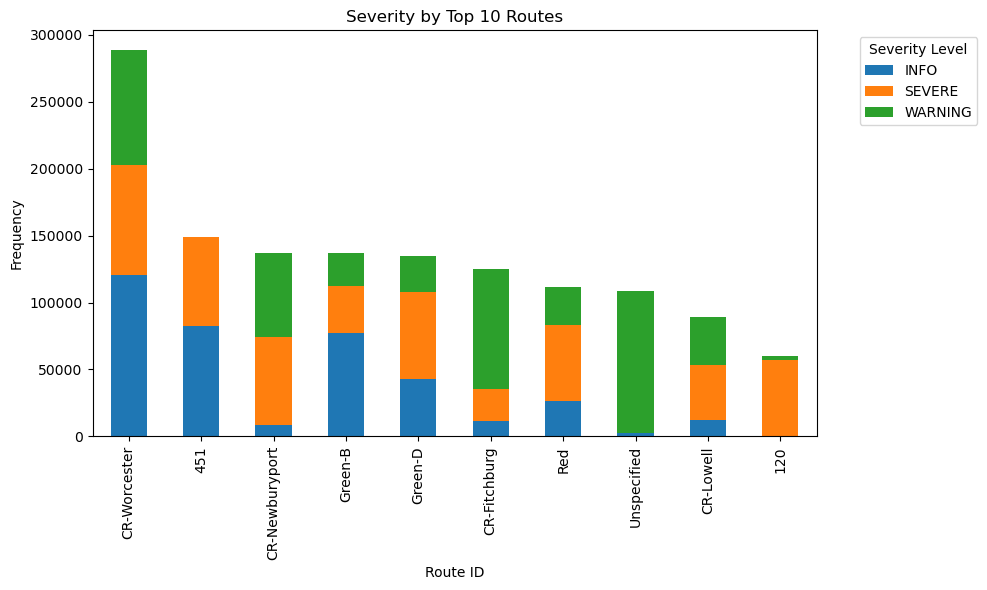

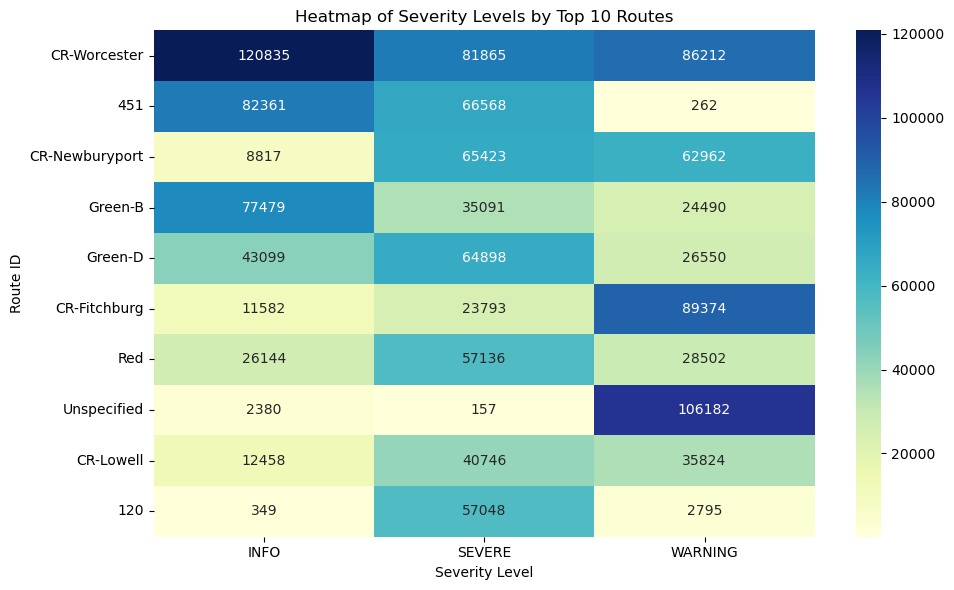

In [56]:
# Most frequent routes
route_counts = merged_alerts_cleaned['route_id'].value_counts()
print("Most Affected Routes:")
print(route_counts.head(10))

# Most frequent stops
stop_counts = merged_alerts_cleaned['stop_id'].value_counts()
print("Most Affected Stops:")
print(stop_counts.head(10))

# Group by 'route_id' and 'severity_level' to calculate frequency
severity_by_route = merged_alerts_cleaned.groupby(['route_id', 'severity_level']).size().unstack(fill_value=0)

# Print the severity distribution for the top 10 routes
top_routes = route_counts.head(10).index.tolist()  # Get the top 10 routes
severity_by_route_top = severity_by_route.loc[top_routes]
print(severity_by_route_top)

# Stacked bar chart for severity levels by top 10 routes
severity_by_route_top.plot(kind='bar', stacked=True, figsize=(10, 6), title='Severity by Top 10 Routes')
plt.xlabel('Route ID')
plt.ylabel('Frequency')
plt.legend(title='Severity Level', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Heatmap for severity levels by top 10 routes
plt.figure(figsize=(10, 6))
sns.heatmap(severity_by_route_top, annot=True, fmt='d', cmap='YlGnBu', cbar=True)
plt.title('Heatmap of Severity Levels by Top 10 Routes')
plt.xlabel('Severity Level')
plt.ylabel('Route ID')
plt.tight_layout()
plt.show()

*SEVERITY BY ROUTE ANALYSIS*

- Green line, major buses, and commuter rail faces the highest numbers of affect. The Green (D) must also be looked at due to its moderately high number of severe alerts. 



### News EDA 

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/mandy.sun/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


Generating Word Cloud for 2024 News Headlines (with custom stopwords)...


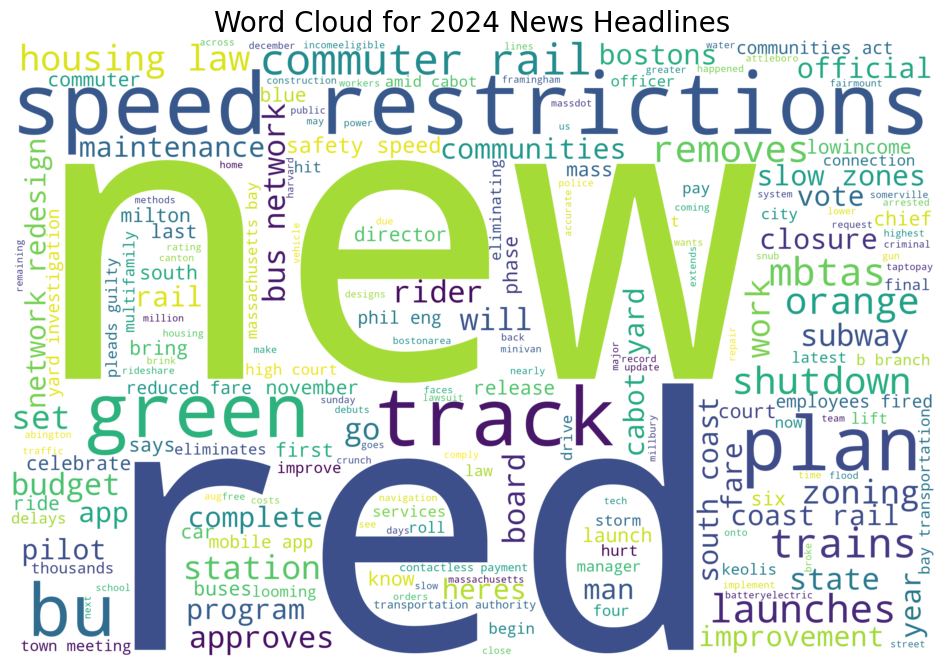

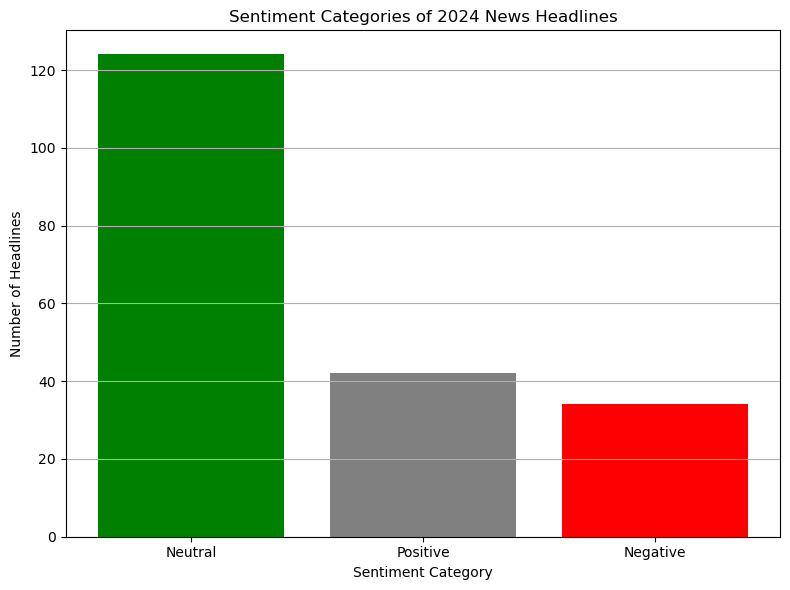

In [62]:
from wordcloud import WordCloud, STOPWORDS
from nltk.sentiment import SentimentIntensityAnalyzer
import re
import nltk

# Load the dataset
file_path = '../../data/raw-data/google_news_revised.csv'
news_data = pd.read_csv(file_path)

# Function to clean text
def clean_text(text):
    if not isinstance(text, str):
        return ''
    try:
        # Remove punctuation and special characters
        text = re.sub(r'[^\w\s]', '', text)
        # Eliminate extra whitespace
        text = re.sub(r'\s+', ' ', text)
        # Convert to lowercase
        text = text.lower()
    except Exception as e:
        print(f"Error cleaning text: {e}")
        text = ''
    return text

# Clean the 'title' column
news_data['cleaned_title'] = news_data['title'].apply(clean_text)

# Add custom stopwords
custom_stopwords = set(STOPWORDS)  # default STOPWORDS
custom_words = {'mbta', 'transit', 'boston', 'train', 'line', 'project', 'service'}  # Added custom stopwords related to MBTA 
custom_stopwords.update(custom_words)

# Function to generate Word Cloud with custom stopwords
def generate_word_cloud(text, title):
    wordcloud = WordCloud(
        width=3000,
        height=2000,
        background_color='white',
        colormap='viridis',
        stopwords=custom_stopwords  
    ).generate(text)

    plt.figure(figsize=(12, 8))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(f"Word Cloud for {title}", fontsize=20)
    plt.show()

# Combine all cleaned titles for word cloud
all_cleaned_text = ' '.join(news_data['cleaned_title'])
print("Generating Word Cloud for 2024 News Headlines (with custom stopwords)...")
generate_word_cloud(all_cleaned_text, "2024 News Headlines")


# Perform Sentiment Analysis Using VADER
sia = SentimentIntensityAnalyzer()

def get_vader_sentiment(text):
    sentiment = sia.polarity_scores(text)
    return sentiment['compound']  # Use the compound score for overall sentiment

# Add sentiment scores
news_data['sentiment_score'] = news_data['cleaned_title'].apply(get_vader_sentiment)

def categorize_sentiment(score):
    if score > 0.1:
        return 'Positive'
    elif score < -0.1:
        return 'Negative'
    else:
        return 'Neutral'

# Apply sentiment categories
news_data['sentiment_category'] = news_data['sentiment_score'].apply(categorize_sentiment)

# Count the number of headlines in each sentiment category
sentiment_counts = news_data['sentiment_category'].value_counts()

# Bar plot for sentiment categories
plt.figure(figsize=(8, 6))
plt.bar(sentiment_counts.index, sentiment_counts.values, color=['green', 'gray', 'red'])
plt.title("Sentiment Categories of 2024 News Headlines")
plt.xlabel("Sentiment Category")
plt.ylabel("Number of Headlines")
plt.grid(axis='y')
plt.tight_layout()
plt.show()



*WORD CLOUD ANALYSIS* 

- Words like "new", "red", "speed", "restrictions", and "network" dominate, suggesting topics surrounding new infrastructure, speed restrictions, and redesigns.
- Challenges Highlighted: Terms like "shutdown", "restrictions", and "slow zones" emphasize difficulties and service limitations. There is also a reference to the MBTA works who were fired. 


*SENTIMENT ANALYSIS* 

- Neutral Dominance: The high frequency of neutral sentiment indicates that many headlines are likely factual, lacking clear emotional tone. This is common in news reporting where objectivity is emphasized.
- Lower Positive and Negative Sentiments: Fewer headlines exhibit strong positivity or negativity, suggesting that while impactful, stories with clear emotional language are less frequent.
- Potential limitation due to news headline being short and concise. Would need to finetune the sentiment process. 



## Financial Statements EDA 

**[Please Click Here to access the financial statement EDA](../eda/financial-eda.ipynb)**

{{< include closing.qmd >}} 